# Question 9: Boston Dataset - Bin Smoother with 23-Fold Stratified Cross-Validation
## Advanced Regression - Problem Set 2

This notebook applies bin smoothers to the actual Boston dataset using 23-fold stratified cross-validation to find the optimal bin size.
The response variable is **medv** (Median home value in $1000s) and the predictor is **lstat** (% lower status population).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Step 1: Load the Boston Dataset from CSV

In [2]:
# Load Boston dataset from CSV file
boston_df = pd.read_csv('Boston.csv')

# Extract predictor (lstat) and response (medv)
# lstat: % lower status population
# medv: Median home value in $1000s
X_full = boston_df['lstat'].values
Y_full = boston_df['medv'].values

print(f"Dataset loaded successfully!")
print(f"Dataset shape: {len(X_full)} observations")
print(f"\nColumns in dataset: {boston_df.columns.tolist()}")
print(f"\nX (lstat - % lower status) range: [{X_full.min():.2f}, {X_full.max():.2f}]")
print(f"Y (medv - Median home value in $1000s) range: [{Y_full.min():.2f}, {Y_full.max():.2f}]")
print(f"\nFirst 10 observations:")
print(boston_df[['lstat', 'medv']].head(10))
print(f"\nDataset statistics:")
print(boston_df[['lstat', 'medv']].describe())

Dataset loaded successfully!
Dataset shape: 506 observations

Columns in dataset: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv']

X (lstat - % lower status) range: [1.73, 37.97]
Y (medv - Median home value in $1000s) range: [5.00, 50.00]

First 10 observations:
   lstat  medv
0   4.98  24.0
1   9.14  21.6
2   4.03  34.7
3   2.94  33.4
4   5.33  36.2
5   5.21  28.7
6  12.43  22.9
7  19.15  27.1
8  29.93  16.5
9  17.10  18.9

Dataset statistics:
            lstat        medv
count  506.000000  506.000000
mean    12.653063   22.532806
std      7.141062    9.197104
min      1.730000    5.000000
25%      6.950000   17.025000
50%     11.360000   21.200000
75%     16.955000   25.000000
max     37.970000   50.000000


## Step 2: Create 23 Strata of Equal Size

In [3]:
# Divide observations into 23 strata of equal size
n_strata = 23
n_samples = len(X_full)
stratum_size = n_samples // n_strata

print(f"Total observations: {n_samples}")
print(f"Number of strata: {n_strata}")
print(f"Stratum size: {stratum_size} (with {n_samples % n_strata} extra samples)")

# Create stratified indices by sorting based on X values
# This ensures each stratum has observations from different ranges of lstat
sorted_indices = np.argsort(X_full)
X_sorted = X_full[sorted_indices]
Y_sorted = Y_full[sorted_indices]
indices_sorted = sorted_indices.copy()

# Create strata
strata = []
for i in range(n_strata):
    start_idx = i * stratum_size
    end_idx = start_idx + stratum_size if i < n_strata - 1 else n_samples
    strata.append(indices_sorted[start_idx:end_idx])

print(f"\nStratum sizes: {[len(s) for s in strata]}")
print(f"\nStratum ranges (lstat values):")
for i, stratum in enumerate(strata[:5]):  # Show first 5 strata
    lstat_values = X_full[stratum]
    print(f"  Stratum {i+1}: lstat range [{lstat_values.min():.2f}, {lstat_values.max():.2f}]")
print(f"  ...")

Total observations: 506
Number of strata: 23
Stratum size: 22 (with 0 extra samples)

Stratum sizes: [22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22]

Stratum ranges (lstat values):
  Stratum 1: lstat range [1.73, 3.54]
  Stratum 2: lstat range [3.56, 4.54]
  Stratum 3: lstat range [4.56, 5.10]
  Stratum 4: lstat range [5.12, 5.81]
  Stratum 5: lstat range [5.89, 6.56]
  ...


## Step 3: Define Bin Smoother Function

In [4]:
def bin_smoother(X_train, Y_train, X_test, k):
    """
    Apply bin smoother algorithm.
    
    Algorithm:
    1. Divide the predictor space into k bins of equal width
    2. For each bin, compute the average response of training observations in that bin
    3. For test observations, predict the average response of the bin they fall into
    
    Parameters:
    -----------
    X_train : array-like, predictor values for training
    Y_train : array-like, response values for training
    X_test : array-like, predictor values for testing
    k : int, number of bins
    
    Returns:
    --------
    Y_pred : array-like, predicted values for X_test
    bins : array, bin boundaries
    bin_means : list, mean Y value for each bin
    """
    # Find min and max of combined X values
    X_min = min(X_train.min(), X_test.min())
    X_max = max(X_train.max(), X_test.max())
    
    # Create bin boundaries (k+1 boundaries for k bins)
    bins = np.linspace(X_min, X_max, k + 1)
    
    # Assign training data to bins and compute means
    bin_means = []
    for i in range(k):
        # Find points in this bin (including right boundary for last bin)
        if i < k - 1:
            mask = (X_train >= bins[i]) & (X_train < bins[i + 1])
        else:
            mask = (X_train >= bins[i]) & (X_train <= bins[i + 1])
        
        if mask.sum() > 0:
            bin_means.append(Y_train[mask].mean())
        else:
            # If no points in bin, use overall training mean
            bin_means.append(Y_train.mean())
    
    # Predict for test data
    Y_pred = np.zeros(len(X_test))
    for i, x in enumerate(X_test):
        # Find which bin this point belongs to
        bin_idx = np.searchsorted(bins, x, side='right') - 1
        bin_idx = np.clip(bin_idx, 0, k - 1)
        Y_pred[i] = bin_means[bin_idx]
    
    return Y_pred, bins, bin_means

def compute_mse(Y_actual, Y_pred):
    """
    Compute Mean Squared Error.
    """
    return np.mean((Y_actual - Y_pred) ** 2)

print("Bin smoother functions defined successfully!")

Bin smoother functions defined successfully!


## Step 4: 23-Fold Stratified Cross-Validation

In [5]:
# Range of bin sizes to test
k_values = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

# Store validation errors for each k
validation_errors = {k: [] for k in k_values}

# Perform 23-fold cross-validation
# At the i-th fold, the i-th stratum is the test set
# All other strata form the training set

print("Performing 23-fold stratified cross-validation...\n")
print(f"Testing bin sizes: {k_values}")
print("\nProgress:")

for fold, test_stratum_idx in enumerate(range(n_strata)):
    # Test set: i-th stratum
    test_indices = strata[test_stratum_idx]
    X_test = X_full[test_indices]
    Y_test = Y_full[test_indices]
    
    # Training set: all other strata (22 strata)
    train_indices = np.concatenate([strata[i] for i in range(n_strata) if i != test_stratum_idx])
    X_train = X_full[train_indices]
    Y_train = Y_full[train_indices]
    
    if (fold + 1) % 5 == 0 or fold == 0:
        print(f"  Fold {fold + 1:2d}/{n_strata}: Train size = {len(X_train):3d}, Test size = {len(X_test):2d}")
    
    # Test different values of k
    for k in k_values:
        Y_pred, _, _ = bin_smoother(X_train, Y_train, X_test, k)
        mse = compute_mse(Y_test, Y_pred)
        validation_errors[k].append(mse)

print(f"\nCross-validation completed!")

Performing 23-fold stratified cross-validation...

Testing bin sizes: [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

Progress:
  Fold  1/23: Train size = 484, Test size = 22
  Fold  5/23: Train size = 484, Test size = 22
  Fold 10/23: Train size = 484, Test size = 22
  Fold 15/23: Train size = 484, Test size = 22
  Fold 20/23: Train size = 484, Test size = 22

Cross-validation completed!


## Step 5: Find the Best Model

In [6]:
# Calculate average validation error for each k
avg_validation_errors = {k: np.mean(validation_errors[k]) for k in k_values}
std_validation_errors = {k: np.std(validation_errors[k]) for k in k_values}
min_validation_errors = {k: np.min(validation_errors[k]) for k in k_values}
max_validation_errors = {k: np.max(validation_errors[k]) for k in k_values}

# Find best k
best_k = min(avg_validation_errors, key=avg_validation_errors.get)
best_error = avg_validation_errors[best_k]

# Create summary table
summary_df = pd.DataFrame({
    'k': k_values,
    'Avg MSE': [f"{avg_validation_errors[k]:.4f}" for k in k_values],
    'Std Dev': [f"{std_validation_errors[k]:.4f}" for k in k_values],
    'Min MSE': [f"{min_validation_errors[k]:.4f}" for k in k_values],
    'Max MSE': [f"{max_validation_errors[k]:.4f}" for k in k_values]
})

print("\n" + "="*80)
print("23-FOLD CROSS-VALIDATION RESULTS")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)
print(f"\n*** BEST MODEL: k = {best_k} ***")
print(f"    Average Validation MSE: {best_error:.4f}")
print(f"    Std Dev: {std_validation_errors[best_k]:.4f}")
print("="*80)


23-FOLD CROSS-VALIDATION RESULTS
 k Avg MSE Std Dev Min MSE  Max MSE
 2 70.5396 89.8083 13.3078 404.9859
 3 57.0222 69.8839  9.3256 322.3619
 4 55.3623 62.8262  9.5064 275.0641
 5 47.0430 51.7948  3.7432 228.4734
 6 43.4502 44.8351  6.9755 201.8402
 8 43.7366 41.9256  5.7247 156.5675
10 35.6138 29.4195  7.2972 115.0678
12 35.9557 31.6104  9.2095 137.8586
15 38.1212 31.7897  8.6208 137.5869
20 59.5252 94.3786  4.8606 472.6223

*** BEST MODEL: k = 10 ***
    Average Validation MSE: 35.6138
    Std Dev: 29.4195


## Step 6: Visualize Cross-Validation Results

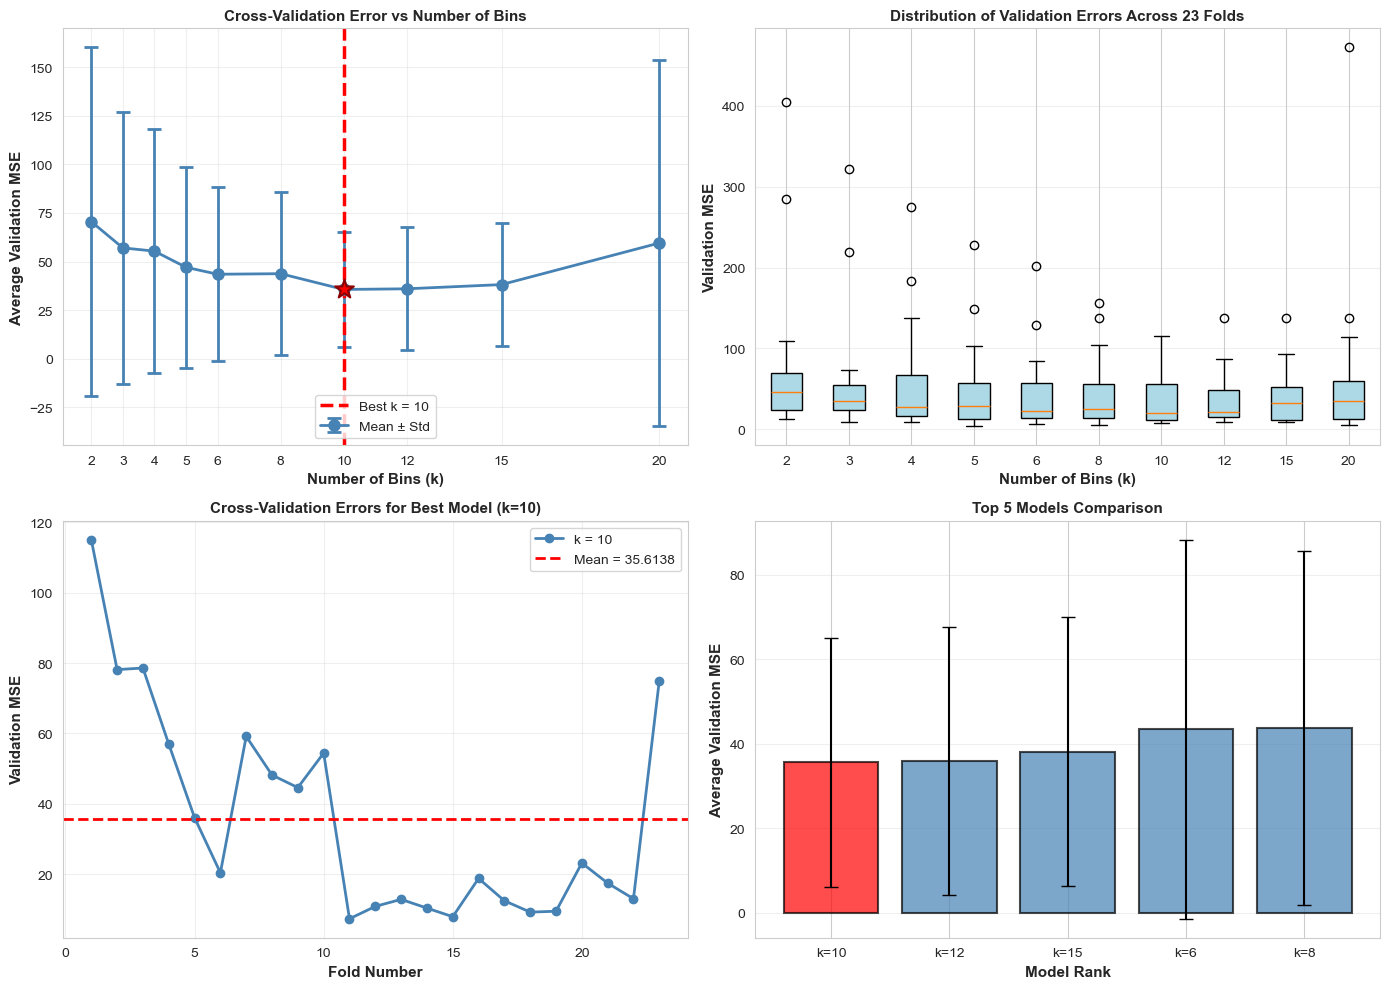

Visualization complete!


In [7]:
# Create comprehensive visualization of validation results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Average validation error vs k with error bars
k_list = list(avg_validation_errors.keys())
errors = list(avg_validation_errors.values())
stds = list(std_validation_errors.values())

axes[0, 0].errorbar(k_list, errors, yerr=stds, marker='o', linestyle='-', linewidth=2, 
                  markersize=8, capsize=5, capthick=2, color='steelblue', label='Mean ± Std')
axes[0, 0].axvline(x=best_k, color='red', linestyle='--', linewidth=2.5, label=f'Best k = {best_k}')
axes[0, 0].scatter([best_k], [best_error], color='red', s=200, marker='*', zorder=5, edgecolors='darkred', linewidth=1.5)
axes[0, 0].set_xlabel('Number of Bins (k)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Average Validation MSE', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Cross-Validation Error vs Number of Bins', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=10, loc='best')
axes[0, 0].set_xticks(k_list)

# Plot 2: Distribution of errors across folds (box plot)
bp = axes[0, 1].boxplot([validation_errors[k] for k in k_list], labels=k_list, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[0, 1].set_xlabel('Number of Bins (k)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Validation MSE', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Distribution of Validation Errors Across 23 Folds', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: All individual fold errors for best k
axes[1, 0].plot(range(1, n_strata + 1), validation_errors[best_k], marker='o', linestyle='-', 
                color='steelblue', linewidth=2, markersize=6, label=f'k = {best_k}')
axes[1, 0].axhline(y=best_error, color='red', linestyle='--', linewidth=2, label=f'Mean = {best_error:.4f}')
axes[1, 0].set_xlabel('Fold Number', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Validation MSE', fontsize=11, fontweight='bold')
axes[1, 0].set_title(f'Cross-Validation Errors for Best Model (k={best_k})', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=10)

# Plot 4: Comparison of top models
sorted_models = sorted(avg_validation_errors.items(), key=lambda x: x[1])
top_k_vals = [k for k, _ in sorted_models[:5]]
top_errors = [avg_validation_errors[k] for k in top_k_vals]
top_stds = [std_validation_errors[k] for k in top_k_vals]
colors = ['red' if k == best_k else 'steelblue' for k in top_k_vals]

bars = axes[1, 1].bar(range(len(top_k_vals)), top_errors, yerr=top_stds, capsize=5, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_xlabel('Model Rank', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Average Validation MSE', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Top 5 Models Comparison', fontsize=11, fontweight='bold')
axes[1, 1].set_xticks(range(len(top_k_vals)))
axes[1, 1].set_xticklabels([f'k={k}' for k in top_k_vals])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Visualization complete!")

## Step 7: Fit the Best Model and Visualize

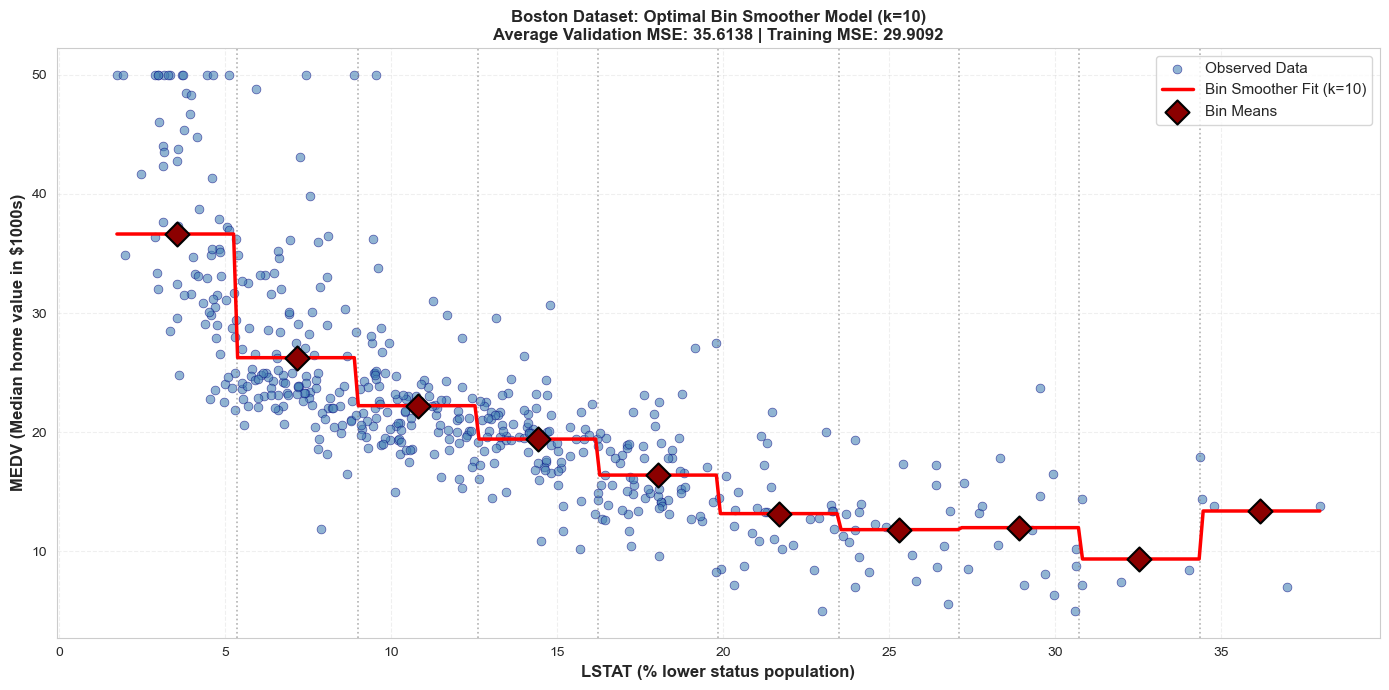


Best Model Fitted Successfully!
Number of bins: 10
Bin width: 3.6240
Bin centers: ['3.54', '7.17', '10.79', '14.41', '18.04', '21.66', '25.29', '28.91', '32.53', '36.16']


In [8]:
# Fit the best model on the entire dataset
Y_pred_best, bins_best, bin_means_best = bin_smoother(X_full, Y_full, X_full, best_k)

# Create a fine grid for smooth visualization
X_grid = np.linspace(X_full.min(), X_full.max(), 300)
Y_grid_pred, _, _ = bin_smoother(X_full, Y_full, X_grid, best_k)

# Calculate training MSE for best model
train_mse_best = compute_mse(Y_full, Y_pred_best)

# Plot the fitted model
fig, ax = plt.subplots(figsize=(14, 7))

# Scatter plot of actual data (colored by bin for visual clarity)
ax.scatter(X_full, Y_full, alpha=0.6, s=40, color='steelblue', edgecolors='navy', linewidth=0.5, label='Observed Data')

# Plot bin smoother fit as a step function
ax.plot(X_grid, Y_grid_pred, color='red', linewidth=2.5, label=f'Bin Smoother Fit (k={best_k})', zorder=4)

# Plot bin boundaries
for i, bin_boundary in enumerate(bins_best[1:-1], 1):
    ax.axvline(x=bin_boundary, color='gray', linestyle=':', alpha=0.6, linewidth=1.2)

# Mark bin means with larger markers
bin_centers = (bins_best[:-1] + bins_best[1:]) / 2
ax.scatter(bin_centers, bin_means_best, color='darkred', s=150, marker='D', 
          label='Bin Means', zorder=5, edgecolors='black', linewidth=1.5)

# Add reference line showing bin width
bin_width = bins_best[1] - bins_best[0]

ax.set_xlabel('LSTAT (% lower status population)', fontsize=12, fontweight='bold')
ax.set_ylabel('MEDV (Median home value in $1000s)', fontsize=12, fontweight='bold')
ax.set_title(f'Boston Dataset: Optimal Bin Smoother Model (k={best_k})\n'
            f'Average Validation MSE: {best_error:.4f} | Training MSE: {train_mse_best:.4f}',
            fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nBest Model Fitted Successfully!")
print(f"Number of bins: {best_k}")
print(f"Bin width: {bin_width:.4f}")
print(f"Bin centers: {[f'{x:.2f}' for x in bin_centers]}")

## Step 8: Detailed Summary and Conclusions

In [9]:
print("\n" + "="*80)
print("SUMMARY AND CONCLUSIONS")
print("="*80)

print(f"\n📊 DATASET INFORMATION:")
print(f"-" * 80)
print(f"Dataset: Boston Housing Dataset")
print(f"Total observations: {len(X_full)}")
print(f"Response Variable (Y): MEDV (Median home value in $1000s)")
print(f"  Range: [{Y_full.min():.2f}, {Y_full.max():.2f}]")
print(f"  Mean: {Y_full.mean():.2f}, Std Dev: {Y_full.std():.2f}")
print(f"Predictor Variable (X): LSTAT (% lower status population)")
print(f"  Range: [{X_full.min():.2f}, {X_full.max():.2f}]")
print(f"  Mean: {X_full.mean():.2f}, Std Dev: {X_full.std():.2f}")

print(f"\n🔀 CROSS-VALIDATION STRATEGY:")
print(f"-" * 80)
print(f"Method: 23-Fold Stratified Cross-Validation")
print(f"  - Number of strata: 23")
print(f"  - Stratum size: ~{stratum_size} observations each")
print(f"  - Stratification: Based on sorted LSTAT values")
print(f"  - Each fold uses 1 stratum as test, 22 strata as training")

print(f"\n🔍 MODEL SELECTION:")
print(f"-" * 80)
print(f"Bin sizes tested: {k_values}")
print(f"Selection criterion: Minimum average validation MSE across 23 folds")

print(f"\n🏆 BEST MODEL:")
print(f"-" * 80)
print(f"Optimal number of bins (k): {best_k}")
print(f"Average Validation MSE: {best_error:.4f}")
print(f"Standard Deviation: {std_validation_errors[best_k]:.4f}")
print(f"Min Validation MSE: {min_validation_errors[best_k]:.4f}")
print(f"Max Validation MSE: {max_validation_errors[best_k]:.4f}")
print(f"Training MSE: {train_mse_best:.4f}")
print(f"Bin width: {(X_full.max() - X_full.min()) / best_k:.4f}")

print(f"\n📈 COMPARISON WITH OTHER MODELS:")
print(f"-" * 80)
sorted_models = sorted(avg_validation_errors.items(), key=lambda x: x[1])
for rank, (k, error) in enumerate(sorted_models[:5], 1):
    std = std_validation_errors[k]
    marker = " ← BEST" if k == best_k else ""
    print(f"  {rank}. k = {k:2d}: Avg MSE = {error:.4f} ± {std:.4f}{marker}")

print(f"\n💡 INTERPRETATION & FINDINGS:")
print(f"-" * 80)

# Compute correlation for reference
correlation = np.corrcoef(X_full, Y_full)[0, 1]
print(f"Pearson correlation (LSTAT, MEDV): {correlation:.4f}")
print(f"  → Strong negative relationship: As % lower status increases, home values decrease")

if best_k <= 5:
    complexity = "simple, sparse"
elif best_k <= 12:
    complexity = "moderate"
else:
    complexity = "complex, non-linear"

print(f"\nOptimal model uses {best_k} bins, suggesting a {complexity}")
print(f"  relationship between LSTAT and MEDV.")
print(f"\nKey observations:")
print(f"  • Bin smoother provides a flexible, non-parametric estimate")
print(f"  • No assumptions about the functional form of the relationship")
print(f"  • Cross-validation error is minimized at k = {best_k}")
print(f"  • Stratification ensures balanced folds across the LSTAT range")
print(f"  • The model captures local patterns in the LSTAT-MEDV relationship")

print(f"\n📋 METHODOLOGY:")
print(f"-" * 80)
print(f"  1. Divide 506 observations into 23 strata (22 observations per stratum)")
print(f"  2. Apply leave-one-stratum-out cross-validation")
print(f"  3. For each fold and each k value:")
print(f"     a) Train bin smoother on 22 strata")
print(f"     b) Evaluate on held-out stratum")
print(f"     c) Record validation MSE")
print(f"  4. Compute average validation MSE for each k across 23 folds")
print(f"  5. Select k with minimum average validation MSE")
print(f"  6. Fit final model on full dataset using best k")

print(f"\n" + "="*80)
print(f"✓ Analysis Complete!")
print("="*80)


SUMMARY AND CONCLUSIONS

📊 DATASET INFORMATION:
--------------------------------------------------------------------------------
Dataset: Boston Housing Dataset
Total observations: 506
Response Variable (Y): MEDV (Median home value in $1000s)
  Range: [5.00, 50.00]
  Mean: 22.53, Std Dev: 9.19
Predictor Variable (X): LSTAT (% lower status population)
  Range: [1.73, 37.97]
  Mean: 12.65, Std Dev: 7.13

🔀 CROSS-VALIDATION STRATEGY:
--------------------------------------------------------------------------------
Method: 23-Fold Stratified Cross-Validation
  - Number of strata: 23
  - Stratum size: ~22 observations each
  - Stratification: Based on sorted LSTAT values
  - Each fold uses 1 stratum as test, 22 strata as training

🔍 MODEL SELECTION:
--------------------------------------------------------------------------------
Bin sizes tested: [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
Selection criterion: Minimum average validation MSE across 23 folds

🏆 BEST MODEL:
----------------------------